In [2]:
from sys import path

path.append("..")

import os
from pathlib import Path

os.chdir(Path.cwd().parent)

In [ ]:
from src.graph_utils.reading import RAW_DIR
import os

arguments_list = []

datasets = list(map(lambda x: '.'.join(x.split('.')[:-1]), filter(lambda x: '.g6' in x, os.listdir(RAW_DIR))))

In [4]:
from src.graph_utils.reading import read_graph6

graphs5 = list(read_graph6('graph5'))
len(graphs5)

34

In [5]:
import networkit as nk
from src.graph_utils.visualisation import plot_graph
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

G = graphs5[24]

APSP = nk.distance.APSP(G)
APSP.run()
distances = np.array(APSP.getDistances())
distances[distances > 10_000] = 0


nx_G = nk.nxadapter.nk2nx(G)
layout = nx.kamada_kawai_layout(nx_G)

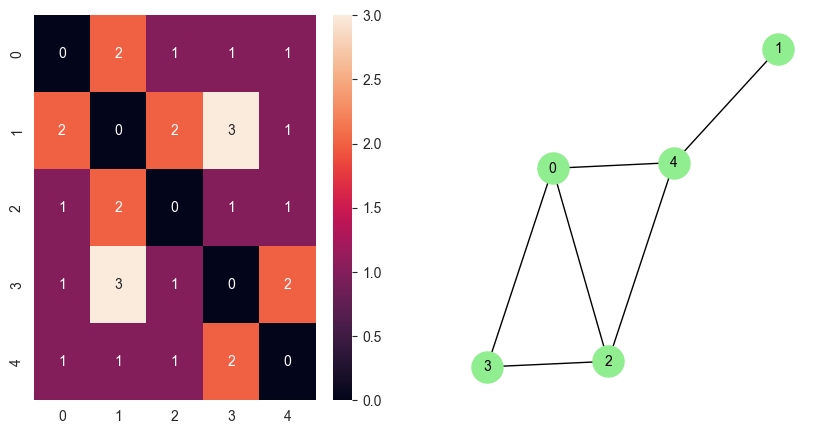

In [6]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10, 5)
sns.heatmap(distances, annot=True, ax=ax[0])
plot_graph(G, layout=layout, ax=ax[1])

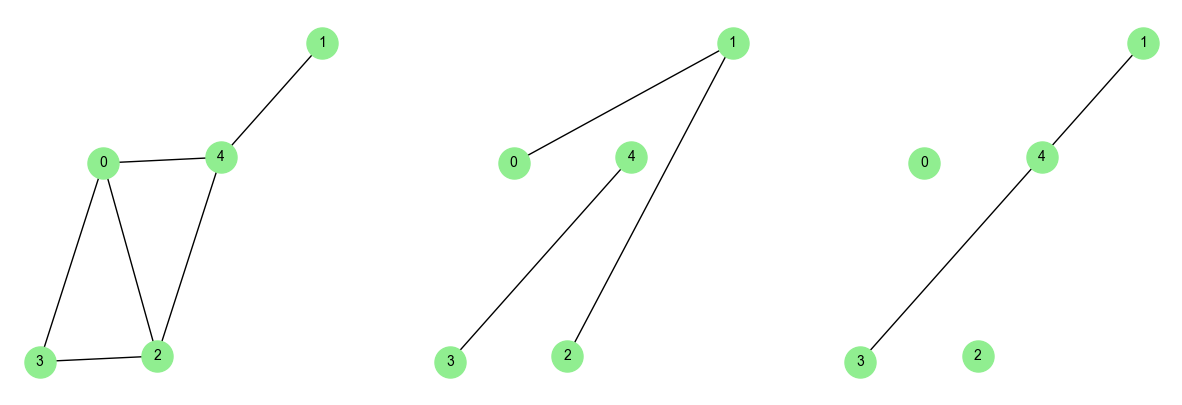

In [7]:
def generate_k_graph(distances: np.ndarray, k: int):

    n = distances.shape[0]
    G = nk.Graph(n)
    new_edges = distances == k

    edges = np.argwhere(new_edges & np.triu(np.ones_like(distances)).astype(bool)).T
    G.addEdges((edges[0], edges[1]))
    return G

fig, ax = plt.subplots(1, 3)
fig.set_size_inches(15, 5)
for k in range(3):
    plot_graph(generate_k_graph(distances, k+1),
            layout=layout,
            ax=ax[k])